<a href="https://colab.research.google.com/github/hariharan-075/ML/blob/main/ML_Week12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)

Dataset Statistics:
Min: 0.0
Max: 1.0
Mean: 0.2860405969887955
Std Dev: 0.35302424451492237


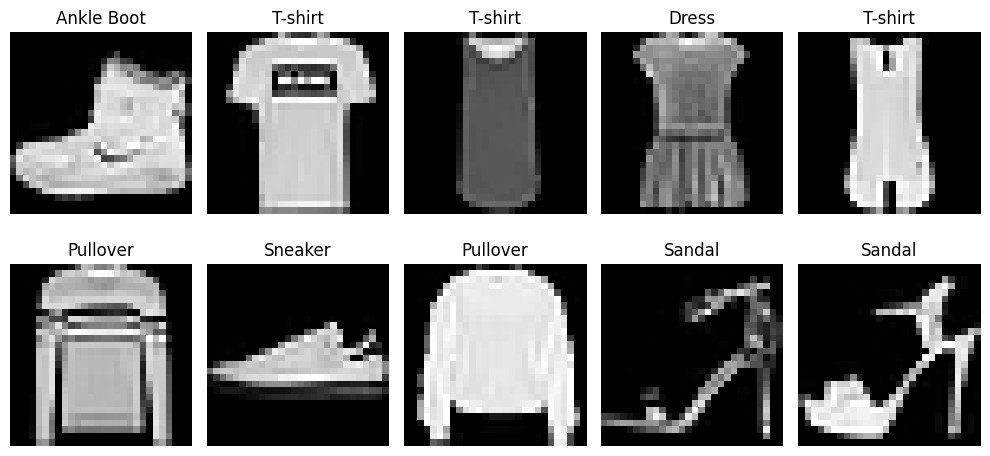

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Normalize pixel values (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten images (28x28 → 784)
X_train_flat = X_train.reshape(len(X_train), -1)

# Dataset statistics
print("\nDataset Statistics:")
print("Min:", X_train.min())
print("Max:", X_train.max())
print("Mean:", X_train.mean())
print("Std Dev:", X_train.std())

# Visualize sample images
labels = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
          "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(labels[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

Explained Variance Ratio: [0.28728633 0.18198231]


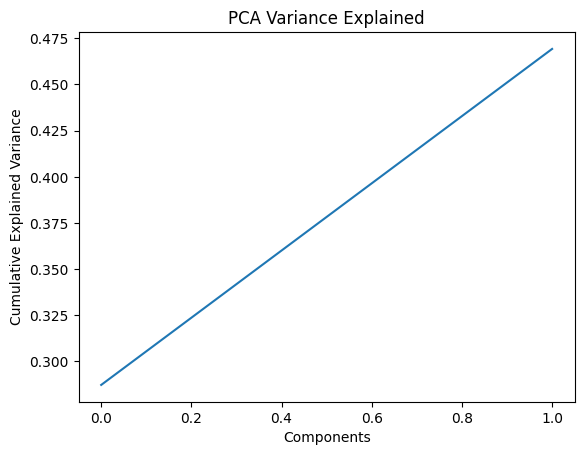

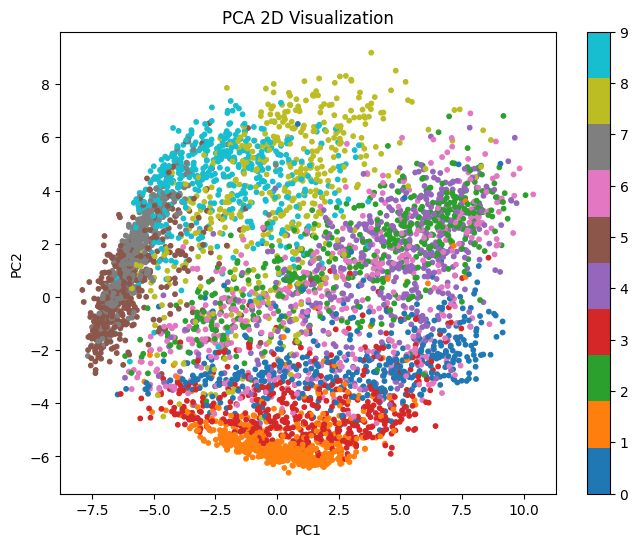

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_flat[:5000])  # use subset for speed

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Plot explained variance
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Explained")
plt.show()

# 2D visualization
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1],
                      c=y_train[:5000], cmap='tab10', s=10)
plt.colorbar(scatter)
plt.title("PCA 2D Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


Running t-SNE with perplexity=5


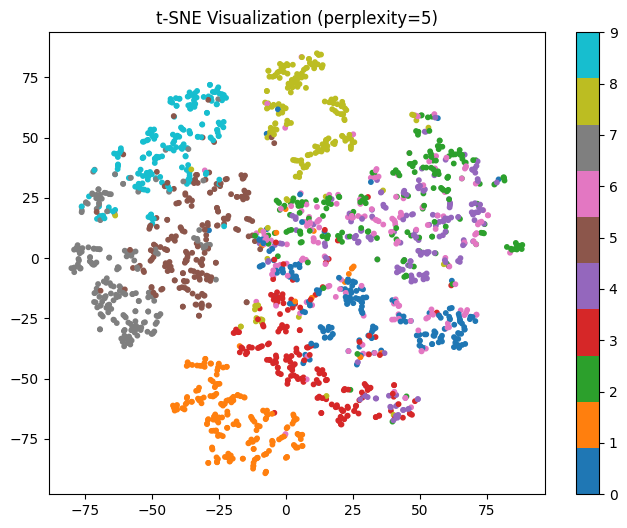


Running t-SNE with perplexity=30


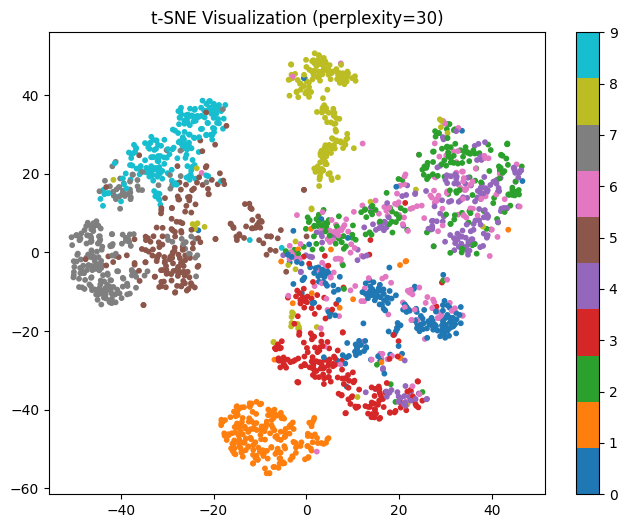


Running t-SNE with perplexity=50


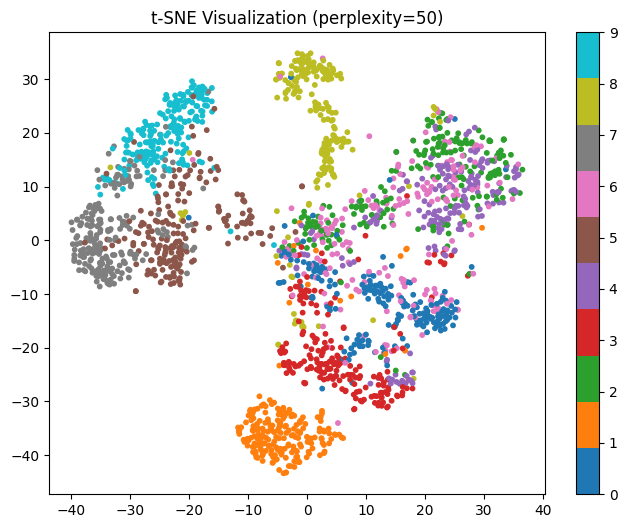

In [ ]:
from sklearn.manifold import TSNE

# Try different perplexities
perplexities = [5, 30, 50]

for p in perplexities:
    print(f"\nRunning t-SNE with perplexity={p}")

    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    X_tsne = tsne.fit_transform(X_train_flat[:2000])  # smaller subset

    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1],
                          c=y_train[:2000], cmap='tab10', s=10)
    plt.colorbar(scatter)
    plt.title(f"t-SNE Visualization (perplexity={p})")
    plt.show()

In [ ]:
import time

# PCA timing
start = time.time()
PCA(n_components=2).fit_transform(X_train_flat[:5000])
print("PCA Time:", time.time() - start)

# t-SNE timing
start = time.time()
TSNE(n_components=2).fit_transform(X_train_flat[:2000])
print("t-SNE Time:", time.time() - start)

PCA Time: 0.20679044723510742
t-SNE Time: 17.67059063911438


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


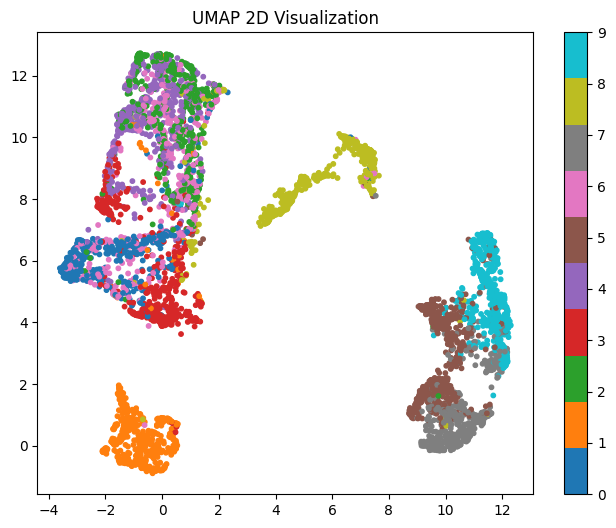

In [ ]:
# Install if needed:
# !pip install umap-learn

import umap

# Apply UMAP
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_train_flat[:5000])

# Plot UMAP
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_umap[:,0], X_umap[:,1],
                      c=y_train[:5000], cmap='tab10', s=10)
plt.colorbar(scatter)
plt.title("UMAP 2D Visualization")
plt.show()

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1180
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0732
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0589
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0501
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0470
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0450
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0439
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0429
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0420
Epoch 10/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0409
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


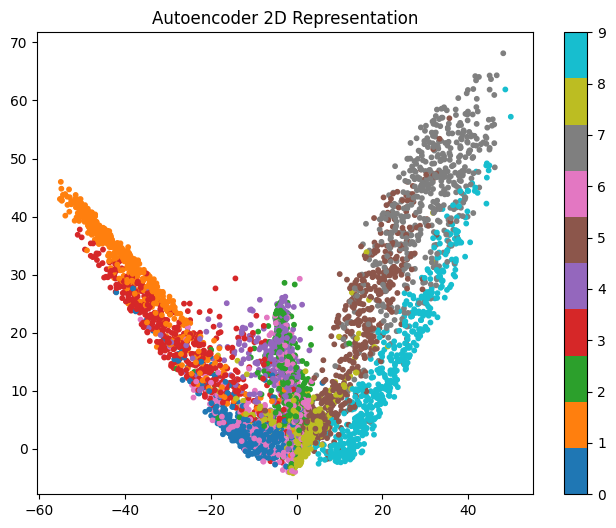

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Autoencoder architecture
input_dim = 784
encoding_dim = 2  # reduce to 2D

input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
latent = Dense(encoding_dim)(encoded)

decoded = Dense(64, activation='relu')(latent)
decoded = Dense(128, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, output_layer)
encoder = Model(input_layer, latent)

autoencoder.compile(optimizer='adam', loss='mse')

# Train
autoencoder.fit(X_train_flat[:10000], X_train_flat[:10000],
                epochs=10, batch_size=256, shuffle=True)

# Encode to 2D
X_ae = encoder.predict(X_train_flat[:5000])

# Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_ae[:,0], X_ae[:,1],
                      c=y_train[:5000], cmap='tab10', s=10)
plt.colorbar(scatter)
plt.title("Autoencoder 2D Representation")
plt.show()

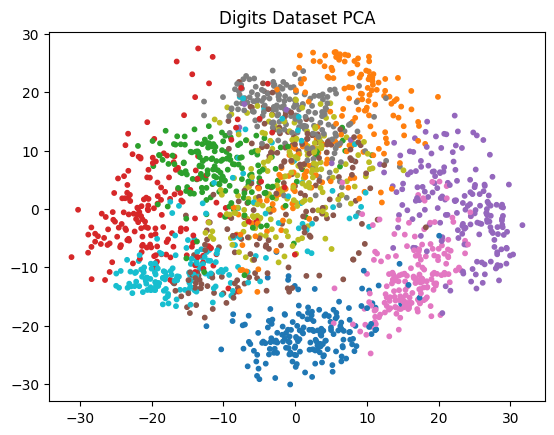

In [ ]:
from sklearn.datasets import load_digits

digits = load_digits()
X_digits = digits.data
y_digits = digits.target

# PCA on digits
X_digits_pca = PCA(n_components=2).fit_transform(X_digits)

plt.scatter(X_digits_pca[:,0], X_digits_pca[:,1],
            c=y_digits, cmap='tab10', s=10)
plt.title("Digits Dataset PCA")
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


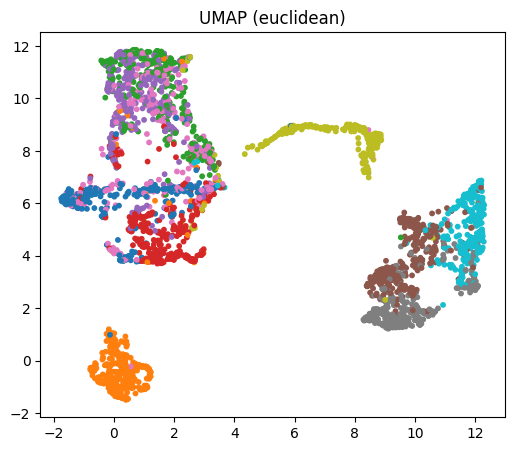

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


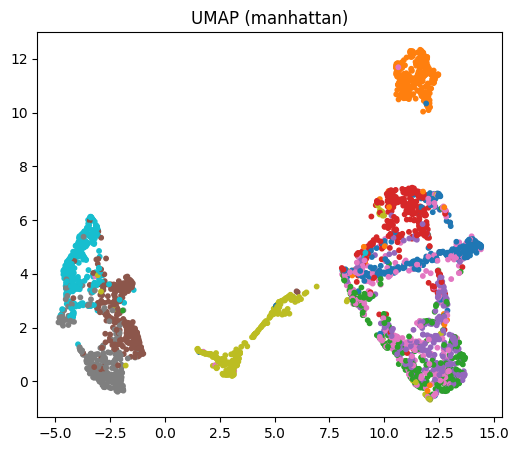

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


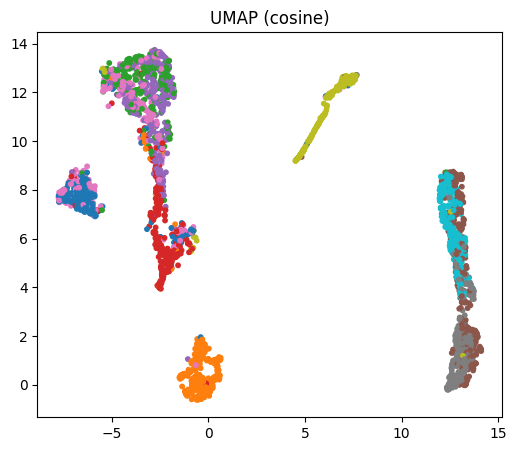

In [ ]:
# UMAP with different metrics
metrics = ['euclidean', 'manhattan', 'cosine']

for metric in metrics:
    reducer = umap.UMAP(n_components=2, metric=metric, random_state=42)
    X_umap_metric = reducer.fit_transform(X_train_flat[:3000])

    plt.figure(figsize=(6,5))
    plt.scatter(X_umap_metric[:,0], X_umap_metric[:,1],
                c=y_train[:3000], cmap='tab10', s=10)
    plt.title(f"UMAP ({metric})")
    plt.show()